Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import datetime 
import warnings
from pathlib import Path
plt.style.use("ggplot")

Load cleaned dataset

In [3]:
def load_dataset(file_path, parse_dates=None):
    return pd.read_csv(file_path, parse_dates=parse_dates)

Inspecting dataset

In [4]:
clean_transactions = load_dataset(
    "../data/clean/cleaned_transactions.csv",
    parse_dates=[
        "transaction_date",
        "signup_date",
    ]
)

In [5]:
clean_transactions.sample(5)

,order_id,customer_id,transaction_date,product_category,quantity,unit_price,revenue,signup_date,acquisition_channel,country,TransactionMonth,Year,Month,DayOfWeek,Quarter,cohort_month
43272,ORD0043273,CUST011991,2024-04-23,Fashion,3,131.93,395.79,2023-11-14,Direct,France,2024-04,2024,4,Tuesday,2,2023-11
17539,ORD0017540,CUST004851,2024-12-19,Beauty,4,94.11,376.44,2024-07-26,Facebook Ads,Germany,2024-12,2024,12,Thursday,4,2024-09
15457,ORD0015458,CUST004260,2023-03-10,Beauty,1,169.15,169.15,2023-01-19,Direct,Germany,2023-03,2023,3,Friday,1,2023-02
44738,ORD0044739,CUST012389,2023-08-10,Electronics,1,37.33,37.33,2023-06-14,Google Ads,France,2023-08,2023,8,Thursday,3,2023-08
61538,ORD0061539,CUST017104,2024-12-17,Home,3,75.40,226.20,2023-09-11,Organic Search,France,2024-12,2024,12,Tuesday,4,2023-10


In [6]:
clean_transactions.dtypes

order_id                       object
customer_id                    object
transaction_date       datetime64[ns]
product_category               object
quantity                        int64
unit_price                    float64
revenue                       float64
signup_date            datetime64[ns]
acquisition_channel            object
country                        object
TransactionMonth               object
Year                            int64
Month                           int64
DayOfWeek                      object
Quarter                         int64
cohort_month                   object
dtype: object

In [7]:
date_cols = ["TransactionMonth"]

clean_transactions[date_cols] = clean_transactions[date_cols].apply(pd.to_datetime)

Recalculate the Cohort Month

In [8]:
clean_transactions["cohort_month"] = (
    clean_transactions.groupby("customer_id")["transaction_date"]
      .transform("min")
      .dt.to_period("M")
)

Calculate the Cohort Index

In [9]:
invoice_year = clean_transactions["TransactionMonth"].dt.year
invoice_month = clean_transactions["TransactionMonth"].dt.month

cohort_year = clean_transactions["cohort_month"].dt.year
cohort_month = clean_transactions["cohort_month"].dt.month

clean_transactions["cohort_index"] = (
    (invoice_year - cohort_year) * 12
    + (invoice_month - cohort_month)
    + 1
)
print(clean_transactions["cohort_index"].head(10))

0    1
1    1
2    2
3    3
4    4
5    5
6    6
7    8
8    1
9    1
Name: cohort_index, dtype: int64


Count Active Customers

In [10]:
cohort_data = (
    clean_transactions.groupby(["cohort_month", "cohort_index"])["customer_id"]
      .nunique()
      .reset_index()
)

cohort_data.head()

,cohort_month,cohort_index,customer_id
0,2023-01,1,159
1,2023-01,2,69
2,2023-01,3,83
3,2023-01,4,57
4,2023-01,5,52


Create the Cohort Matrix

In [11]:
cohort_matrix = cohort_data.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

cohort_matrix

cohort_index,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
cohort_month,,,,,,,,,,,,,,,,,,,,,
2023-01,159.0,69.0,83.0,57.0,52.0,36.0,41.0,28.0,24.0,21.0,...,4.0,3.0,2.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN
2023-02,541.0,277.0,238.0,216.0,156.0,134.0,104.0,73.0,69.0,60.0,...,17.0,10.0,13.0,8.0,8.0,4.0,4.0,4.0,2.0,3.0
2023-03,851.0,411.0,409.0,317.0,251.0,194.0,140.0,121.0,83.0,70.0,...,31.0,23.0,15.0,15.0,11.0,7.0,9.0,5.0,5.0,NaN
2023-04,797.0,406.0,382.0,306.0,253.0,194.0,156.0,126.0,96.0,81.0,...,29.0,31.0,27.0,19.0,16.0,13.0,10.0,9.0,NaN,NaN
2023-05,888.0,451.0,425.0,317.0,265.0,215.0,158.0,138.0,111.0,73.0,...,34.0,28.0,18.0,17.0,15.0,10.0,9.0,NaN,NaN,NaN
2023-06,791.0,380.0,391.0,277.0,228.0,182.0,156.0,128.0,110.0,86.0,...,42.0,25.0,26.0,16.0,17.0,16.0,NaN,NaN,NaN,NaN
2023-07,886.0,425.0,443.0,300.0,249.0,211.0,160.0,117.0,93.0,87.0,...,43.0,28.0,22.0,30.0,16.0,NaN,NaN,NaN,NaN,NaN
2023-08,837.0,430.0,427.0,352.0,267.0,210.0,183.0,141.0,114.0,94.0,...,31.0,26.0,24.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,851.0,439.0,390.0,332.0,264.0,197.0,172.0,132.0,110.0,74.0,...,36.0,27.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
cohort_matrix.to_csv(
    "../data/cohort_data/cohort_matrix.csv"
)

Calculate the Retention Rate

In [13]:
retention_matrix = cohort_matrix.divide(
    cohort_matrix.iloc[:, 0],
    axis=0
)

In [14]:
retention_matrix = retention_matrix.round(3) * 100

In [15]:
retention_matrix.to_csv(
    "../data/cohort_data/retention_matrix.csv"
)

Create the Heatmap

FileNotFoundError: [Errno 2] No such file or directory: '../visuals/retention_heatmap.png'

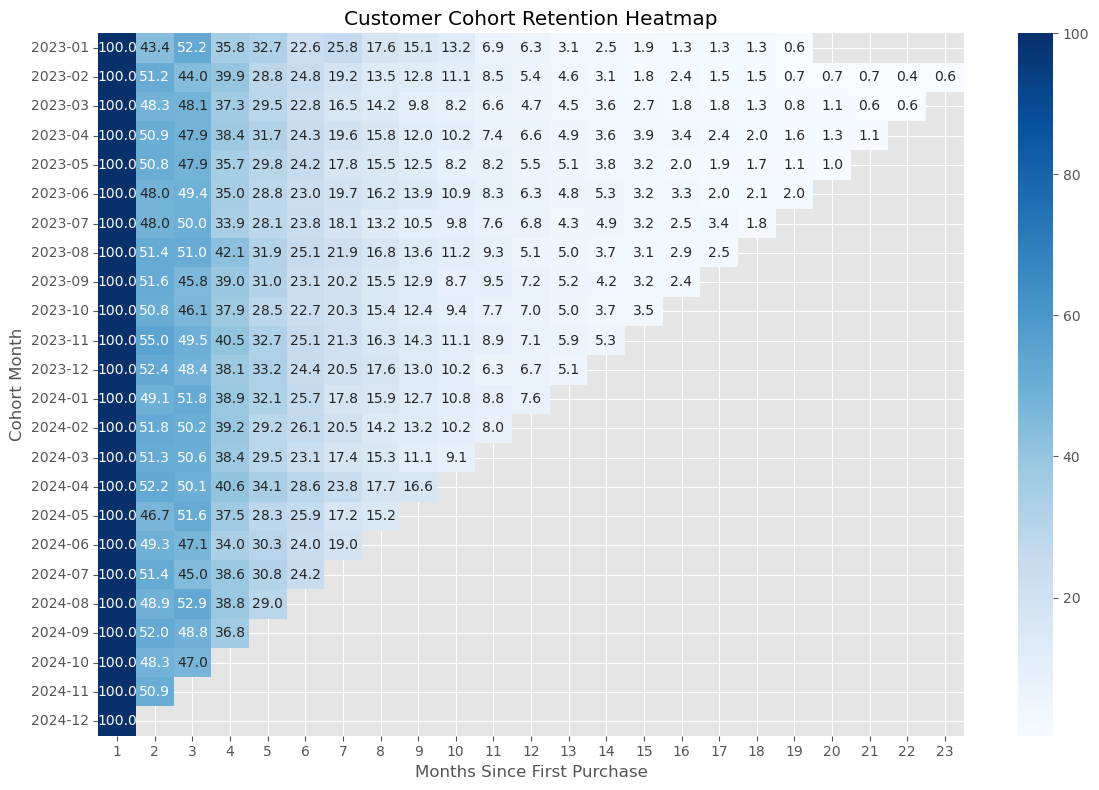

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Customer Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()

plt.savefig(
    "../visuals/retention_heatmap.png",
    dpi=300
)

plt.show()

Key Findings
January cohort retained 82% of customers after Month 2.
Retention consistently declined across all cohorts.
Most customer churn occurred between Month 1 and Month 2.
Later cohorts showed slightly stronger early retention than earlier cohorts.